C:\Users\stuen\AppData\Local\Temp\ipykernel_3884\245218799.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  prod["Dato"] = pd.to_datetime(prod["Dato"], dayfirst=True)


                 Dato  [MWh]  Price_ore_kWh
0 2025-01-01 01:00:00    0.0          7.030
1 2025-01-02 01:00:00    0.0          8.753
2 2025-01-03 01:00:00    0.0          9.019
3 2025-01-04 01:00:00    0.0          8.504
4 2025-01-05 01:00:00    0.0          7.063
Index(['Dato', '[MWh]', 'Price_ore_kWh'], dtype='str')
Antall timer totalt: 365
Antall driftstimer: 258
=== NØKKELTALL CASE 2 - VIRKNINGSGRADSANALYSE ===
Total energi i drift: 6792.0 MWh
Gjennomsnittlig virkningsgrad i drift: 60.75 %
Energivektet virkningsgrad: 82.36 %
Timer med høy virkningsgrad: 101
Andel driftstimer med høy virkningsgrad: 49.5 %
Andel energi produsert med høy virkningsgrad: 73.1 %

Fordeling etter virkningsgrad:
eta_kategori
Høy virkningsgrad        101
Lav virkningsgrad         71
Middels virkningsgrad     32
Name: count, dtype: int64
Beste modellert virkningsgrad: 92.00 %

=== TAPT ENERGI PGA. LAV VIRKNINGSGRAD ===
Faktisk energi: 6792.0 MWh
Teoretisk energi ved beste virkningsgrad: 7518.1 MWh
Tapt energi

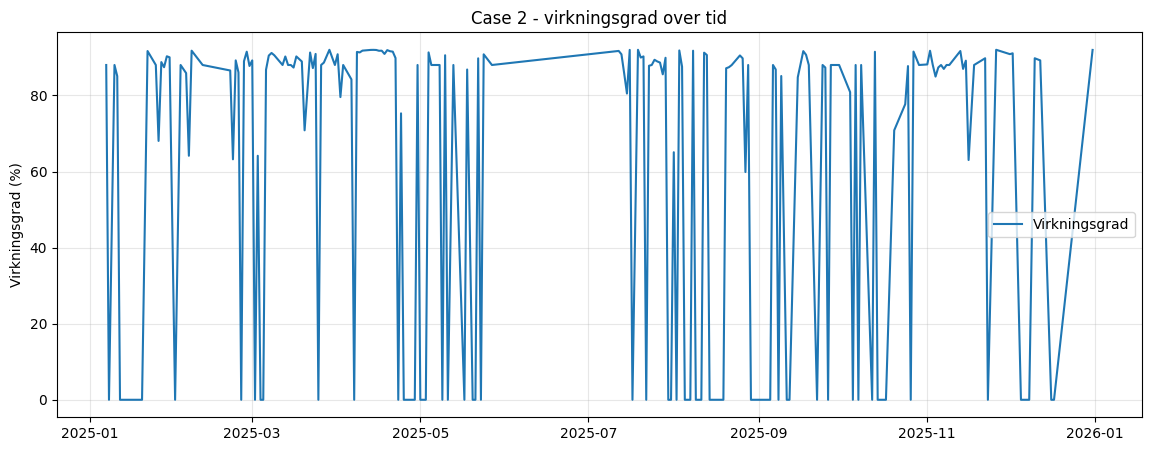

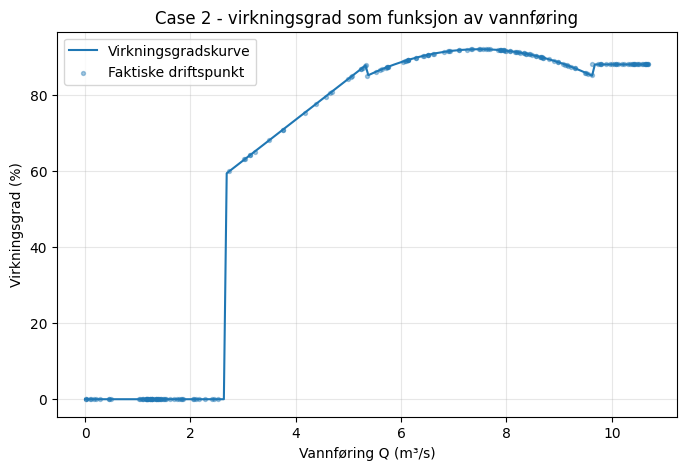

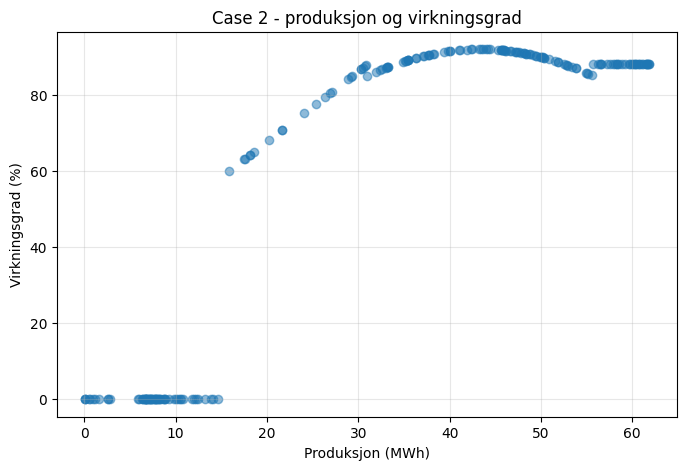

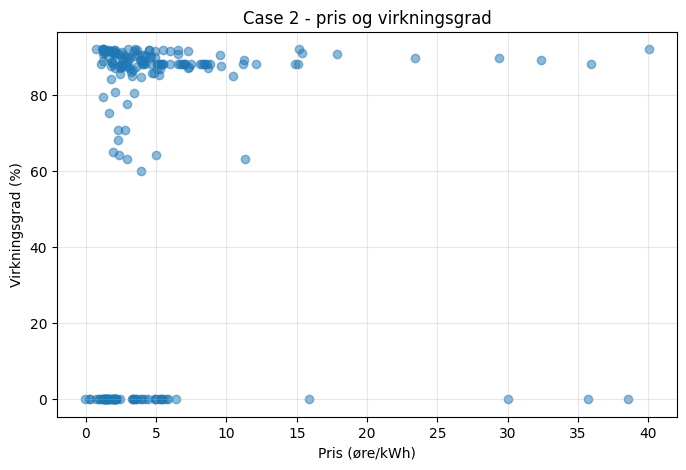

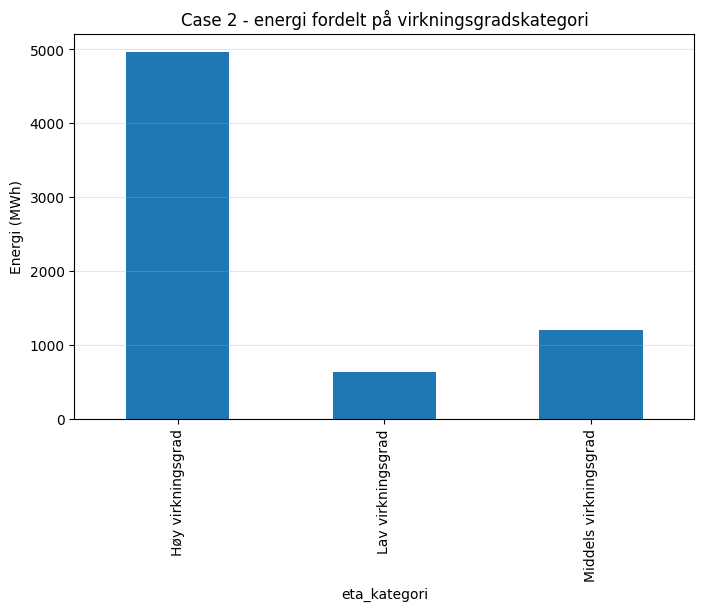

In [42]:
# CASE 2 - VIRKNINGSGRADSANALYSE AV FAKTISK DRIFT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prod = pd.read_excel("Sildvik_2025_produksjon_ferdig.xlsx")
prod.columns = prod.columns.str.strip()

prod["Dato"] = pd.to_datetime(prod["Dato"], dayfirst=True)
prod["[MWh]"] = pd.to_numeric(prod["[MWh]"], errors="coerce")

pris = pd.read_excel("Pris_2025 (1).xlsx")
pris.columns = pris.columns.str.strip()

pris = pris.rename(columns={
    "Dato, time": "Dato",
    "Gjennomsnitt Pris (øre/kWh)": "Price_ore_kWh"
})

pris["Dato"] = pd.to_datetime(pris["Dato"], dayfirst=True)
pris["Price_ore_kWh"] = pd.to_numeric(pris["Price_ore_kWh"], errors="coerce")

df = pd.merge(prod, pris, on="Dato", how="inner")
df = df.sort_values("Dato").reset_index(drop=True)
df = df.dropna().copy()

# Fjern nullproduksjon fra virkningsgradsanalyse
drift = df[df["[MWh]"] > 0].copy()

print(df.head())
print(df.columns)
print(f"Antall timer totalt: {len(df)}")
print(f"Antall driftstimer: {len(drift)}")

rho = 1000
g = 9.81
H_brutto = 655
Q_max = 10.7
eta_ref = 0.90

# Produksjon i én time: MWh tilsvarer gjennomsnittlig MW
drift["P_MW"] = drift["[MWh]"]

# Estimert vannføring fra faktisk produksjon
drift["Power_W"] = drift["P_MW"] * 1e6
drift["Q_m3s"] = drift["Power_W"] / (eta_ref * rho * g * H_brutto)

# Fjerner eventuelle urealistiske verdier
drift = drift[(drift["Q_m3s"] > 0) & (drift["Q_m3s"] <= Q_max)].copy()

# Falltap og netto fallhøyde
k_loss = 5.2 / (11.0**2)

def h_loss(Q):
    return k_loss * Q**2

drift["h_loss_m"] = h_loss(drift["Q_m3s"])
drift["H_netto_m"] = H_brutto - drift["h_loss_m"]

def eta_category(eta):
    if eta >= 0.88:
        return "Høy virkningsgrad"
    elif eta >= 0.75:
        return "Middels virkningsgrad"
    else:
        return "Lav virkningsgrad"

eta_max = 0.93

def eta_turbin(Q):
    if np.isscalar(Q):
        if Q <= 0:
            return 0.0

        q_rel = Q / Q_max

        if q_rel < 0.25:
            return 0.0
        elif q_rel < 0.50:
            return 0.65 + (q_rel - 0.30) * (0.88 - 0.65) / 0.20
        elif q_rel < 0.90:
            return 0.85 + 0.07 * (1 - ((q_rel - 0.70) / 0.20)**2)
        elif q_rel <= 1.00:
            return 0.88
        else:
            return 0.0

    Q = np.asarray(Q, dtype=float)
    out = np.zeros_like(Q, dtype=float)

    q_rel = Q / Q_max

    mask_1 = (q_rel >= 0.25) & (q_rel < 0.50)
    mask_2 = (q_rel >= 0.50) & (q_rel < 0.90)
    mask_3 = (q_rel >= 0.90) & (q_rel <= 1.00)

    out[mask_1] = 0.65 + (q_rel[mask_1] - 0.30) * (0.88 - 0.65) / 0.20
    out[mask_2] = 0.85 + 0.07 * (1 - ((q_rel[mask_2] - 0.70) / 0.20)**2)
    out[mask_3] = 0.88

    return out

drift["eta_model"] = eta_turbin(drift["Q_m3s"].values)
drift["q_rel"] = drift["Q_m3s"] / Q_max

drift["eta_kategori"] = drift["eta_model"].apply(eta_category)

# Nøkkeltall for virkningsgradsanalyse

total_energy = drift["[MWh]"].sum()
avg_eta = drift["eta_model"].mean()
weighted_eta = (drift["eta_model"] * drift["[MWh]"]).sum() / drift["[MWh]"].sum()

hours_high_eta = (drift["eta_model"] >= 0.88).sum()
share_high_eta = hours_high_eta / len(drift) * 100

energy_high_eta = drift.loc[drift["eta_model"] >= 0.88, "[MWh]"].sum()
share_energy_high_eta = energy_high_eta / total_energy * 100

print("=== NØKKELTALL CASE 2 - VIRKNINGSGRADSANALYSE ===")
print(f"Total energi i drift: {total_energy:.1f} MWh")
print(f"Gjennomsnittlig virkningsgrad i drift: {avg_eta*100:.2f} %")
print(f"Energivektet virkningsgrad: {weighted_eta*100:.2f} %")
print(f"Timer med høy virkningsgrad: {hours_high_eta}")
print(f"Andel driftstimer med høy virkningsgrad: {share_high_eta:.1f} %")
print(f"Andel energi produsert med høy virkningsgrad: {share_energy_high_eta:.1f} %")
#print("Økonomisk tap:", drift["Lost_value_NOK"].sum(), "kr")

print("\nFordeling etter virkningsgrad:")
print(drift["eta_kategori"].value_counts())

# Tap i forhold til beste virkningsgrad

# Finner beste virkningsgrad i modellen
Q_test = np.linspace(0, Q_max, 500)
eta_test = np.array([eta_turbin(Q) for Q in Q_test])
eta_best = eta_test.max()

print(f"Beste modellert virkningsgrad: {eta_best*100:.2f} %")

# Falltap og netto fallhøyde
k_loss = 5.2 / (11.0**2)

def h_loss(Q):
    return k_loss * Q**2

drift["h_loss_m"] = h_loss(drift["Q_m3s"])
drift["H_netto_m"] = H_brutto - drift["h_loss_m"]

# Hydraulisk effekt tilgjengelig ved faktisk vannføring
drift["P_hyd_MW"] = (
    rho * g * drift["Q_m3s"] * drift["H_netto_m"] / 1e6
)

# Faktisk modellert effekt med aktuell virkningsgrad
drift["P_model_MW"] = drift["P_hyd_MW"] * drift["eta_model"]

# Teoretisk effekt hvis samme vannmengde ble kjørt med beste virkningsgrad
drift["P_best_eta_MW"] = drift["P_hyd_MW"] * eta_best

# Tapt energi per time
drift["Lost_energy_MWh"] = drift["P_best_eta_MW"] - drift["P_model_MW"]
drift["Lost_energy_MWh"] = drift["Lost_energy_MWh"].clip(lower=0)

# Nøkkeltall
total_lost_energy = drift["Lost_energy_MWh"].sum()
actual_energy = drift["[MWh]"].sum()
potential_energy = actual_energy + total_lost_energy

print("\n=== TAPT ENERGI PGA. LAV VIRKNINGSGRAD ===")
print(f"Faktisk energi: {actual_energy:.1f} MWh")
print(f"Teoretisk energi ved beste virkningsgrad: {potential_energy:.1f} MWh")
print(f"Tapt energi pga. lavere virkningsgrad: {total_lost_energy:.1f} MWh")
print(f"Andel tapt energi: {total_lost_energy / potential_energy * 100:.2f} %")

# PLOTS CASE 2 - VIRKNINGSGRAD

plt.figure(figsize=(14,5))
plt.plot(drift["Dato"], drift["eta_model"] * 100, label="Virkningsgrad")
plt.title("Case 2 - virkningsgrad over tid")
plt.ylabel("Virkningsgrad (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Plot 2: Virkningsgrad som funksjon av vannføring

Q_plot = np.linspace(0, Q_max, 200)
eta_plot = [eta_turbin(Q) for Q in Q_plot]

plt.figure(figsize=(8,5))
plt.plot(Q_plot, np.array(eta_plot) * 100, label="Virkningsgradskurve")
plt.scatter(drift["Q_m3s"], drift["eta_model"] * 100, s=8, alpha=0.4, label="Faktiske driftspunkt")
plt.title("Case 2 - virkningsgrad som funksjon av vannføring")
plt.xlabel("Vannføring Q (m³/s)")
plt.ylabel("Virkningsgrad (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Plot 3: Produksjon vs virkningsgrad

plt.figure(figsize=(8,5))
plt.scatter(drift["[MWh]"], drift["eta_model"] * 100, alpha=0.5)
plt.title("Case 2 - produksjon og virkningsgrad")
plt.xlabel("Produksjon (MWh)")
plt.ylabel("Virkningsgrad (%)")
plt.grid(True, alpha=0.3)
plt.show()

# Plot 4: Pris vs virkningsgrad

plt.figure(figsize=(8,5))
plt.scatter(drift["Price_ore_kWh"], drift["eta_model"] * 100, alpha=0.5)
plt.title("Case 2 - pris og virkningsgrad")
plt.xlabel("Pris (øre/kWh)")
plt.ylabel("Virkningsgrad (%)")
plt.grid(True, alpha=0.3)
plt.show()

# Plot 5: Energi fordelt på virkningsgradskategorier

energy_by_eta = drift.groupby("eta_kategori")["[MWh]"].sum()

plt.figure(figsize=(8,5))
energy_by_eta.plot(kind="bar")
plt.title("Case 2 - energi fordelt på virkningsgradskategori")
plt.ylabel("Energi (MWh)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [37]:
drift["Lost_value_NOK"] = drift["Lost_energy_MWh"] * drift["Price_ore_kWh"] * 10
# SESONGANALYSE

def season(month):
    if month in [12, 1, 2]:
        return "Vinter"
    elif month in [3, 4, 5]:
        return "Vår"
    elif month in [6, 7, 8]:
        return "Sommer"
    else:
        return "Høst"

drift["Måned"] = drift["Dato"].dt.month
drift["Sesong"] = drift["Måned"].apply(season)

season_summary = drift.groupby("Sesong").agg(
    Energi_MWh=("[MWh]", "sum"),
    Snitt_virkningsgrad=("eta_model", "mean"),
    Energivektet_virkningsgrad=("eta_model", lambda x: np.average(x, weights=drift.loc[x.index, "[MWh]"])),
    Tapt_energi_MWh=("Lost_energy_MWh", "sum"),
    Tapt_verdi_NOK=("Lost_value_NOK", "sum"),
    Snitt_pris_ore_kWh=("Price_ore_kWh", "mean")
)

season_summary["Snitt_virkningsgrad"] *= 100
season_summary["Energivektet_virkningsgrad"] *= 100

season_summary

,Energi_MWh,Snitt_virkningsgrad,Energivektet_virkningsgrad,Tapt_energi_MWh,Tapt_verdi_NOK,Snitt_pris_ore_kWh
Sesong,,,,,,
Høst,1798.8,61.219253,83.071139,178.053693,10246.605927,6.603961
Sommer,1357.6,53.039848,80.161757,178.369688,3261.529114,2.220000
Vinter,1197.8,59.721927,81.330248,141.809911,14886.534233,10.069846
Vår,2437.8,66.215223,83.575213,227.828410,6855.543590,3.272691


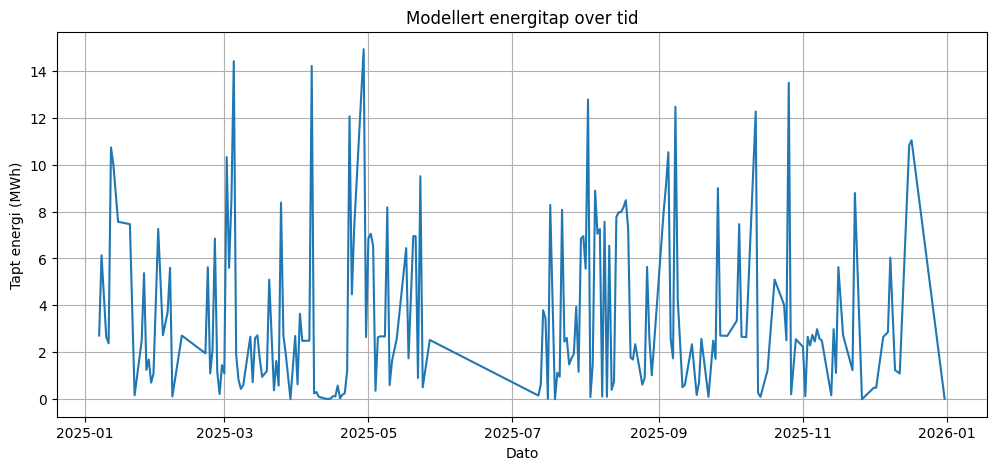

In [38]:
plt.figure(figsize=(12,5))
plt.plot(drift["Dato"], drift["Lost_energy_MWh"])
plt.title("Modellert energitap over tid")
plt.xlabel("Dato")
plt.ylabel("Tapt energi (MWh)")
plt.grid(True)
plt.show()

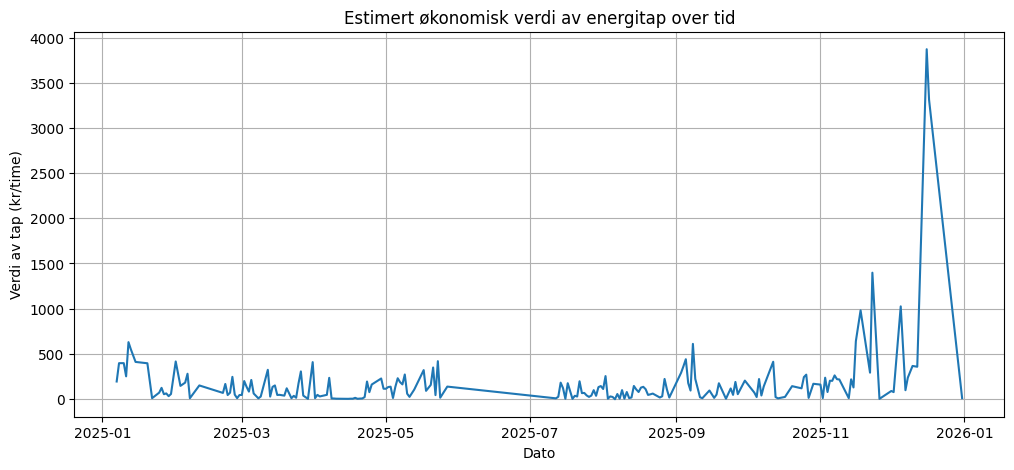

In [39]:
plt.figure(figsize=(12,5))
plt.plot(drift["Dato"], drift["Lost_value_NOK"])
plt.title("Estimert økonomisk verdi av energitap over tid")
plt.xlabel("Dato")
plt.ylabel("Verdi av tap (kr/time)")
plt.grid(True)
plt.show()

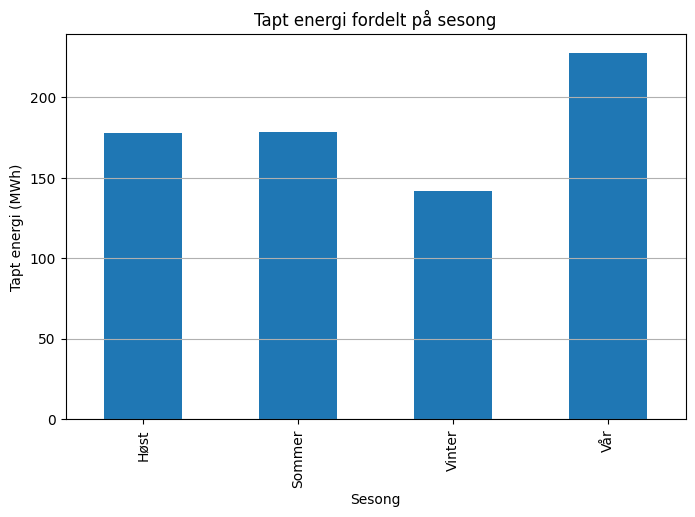

In [40]:
season_summary["Tapt_energi_MWh"].plot(kind="bar", figsize=(8,5))
plt.title("Tapt energi fordelt på sesong")
plt.ylabel("Tapt energi (MWh)")
plt.xlabel("Sesong")
plt.grid(axis="y")
plt.show()


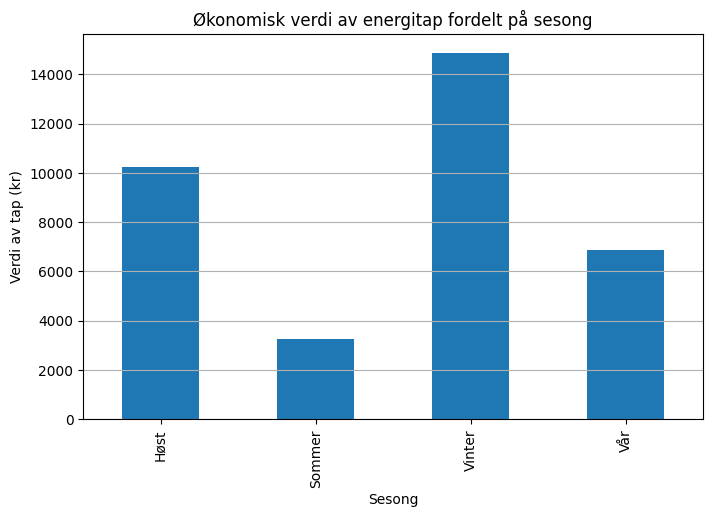

In [41]:
season_summary["Tapt_verdi_NOK"].plot(kind="bar", figsize=(8,5))
plt.title("Økonomisk verdi av energitap fordelt på sesong")
plt.ylabel("Verdi av tap (kr)")
plt.xlabel("Sesong")
plt.grid(axis="y")
plt.show()

In [ ]:
# Svakheter med denne modellen:

# I praksis påvirkes total virkningsgrad også av:
#generator, transformator, hjelpesystemer, delasttap

# Virkningsgradskurven er forenklet og basert på generelle antakelser:
# Det betyr: ikke basert på faktisk hill chart, ikke levert av turbineleverandør, ikke testdata fra anlegget 

# Konstant brutto fallhøyde

# Forenklet falltap

# Modellen antar at alle nulltimer er økonomiske valg. Tar ikke hensyn til tekniske begrensninger, vedlikehold, eller andre faktorer som kan påvirke driftsbeslutninger.


# Kan forbedres ved å:
# Inkludere flere faktorer i virkningsgradskurven, som generator og transformator
# Bruke faktisk hill chart eller testdata for å kalibrere modellen
# Inkludere variasjoner i brutto fallhøyde gjennom en graf etc
